# Homework 2

### Deadline: Wednesday 14 May 2024 (by 19h00)

### Credits: 20 points

### Instructions:

- When you finish, please submit a single **.ipynb** file via email to wbanda@yachaytech.edu.ec


- The homework is individual. Please include your name in the notebook.


- Within a **single python notebook**, solve the following problems.

## Name: Silva Alejandro

# The Orszag-Tang vortex: Calculus and Fourier analysis (20 points)

We want to study the properties of turbulent flows using numerical calculus and Fourier analysis. Let us consider the Orszag-Tang vortex system, which describes a doubly periodic fluid configuration leading to 2D supersonic magnetohydrodynamical (MHD) turbulence. Although an analytical solution is not known, its simple and reproducible set of initial conditions has made it a widespread benchmark for the comparison of MHD numerical solvers.

The computational domain is periodic box with dimensions: $[0,2\pi]^D$ where $D$ is the number of spatial dimensions.

In code units, the initial conditions are given by:
$
     \vec{v} = \left(-\sin y,\, \sin x\right) \,,\qquad
     \vec{B} = \left(-\sin y,\, \sin 2x\right) \,,\qquad
     \rho = 25/9\,,\qquad
     p    = 5/3
$

The numerical simulation produces $61$ VTK files stored in:

- the **Orszag-Tang-MHD** folder: 

https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/Orszag_Tang-MHD.zip

jointly with:

- a **units.out** file that contains the CGS normalisation values.
- a **vtk.out** file whose second column contains the times in code units.
- a **grid.out** file that contains information on the grid structure.

You can use VisIt to inspect the data. The written fields are: 

- density (rho)
- thermal pressure (prs)
- velocity_x (vx1)
- velocity_y (vx2)
- magnetic_field_x (Bx1)
- magnetic_field_y (Bx2)

**Reference paper:**
https://arxiv.org/pdf/1001.2832.pdf

"High-order conservative finite difference GLM-MHD schemes for cell-centered MHD", Mignone, Tzeferacos & Bodo, JCP (2010) 229, 5896.

### Requirements and paths
The following libraries and specification of paths are required to run this notebook.

In [1]:
#Import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
import pandas as pd
from PIL import Image, ImageDraw
import glob 
from IPython import display
import os

In [2]:
## Input
input_path_data = "./data/Orszag_Tang-MHD/" #change to your working directory, where you have the files folder

In [3]:
# Create an output folder
if os.path.isdir("./output_n"):
    print("Directory already exists.")
else:
    print("Directory has been created.")
    os.mkdir("./output_n")

Directory already exists.


In [4]:
#Specify the output path
output_path_data_1 = "./output_n"

In [5]:
# Create an output folder
if os.path.isdir("./output_s"):
    print("Directory already exists.")
else:
    print("Directory has been created.")
    os.mkdir("./output_s")

Directory already exists.


In [6]:
#Specify the output path
output_path_data_2 = "./output_s"

In [7]:
# Create an output folder
if os.path.isdir("./output_f"):
    print("Directory already exists.")
else:
    print("Directory has been created.")
    os.mkdir("./output_f")

Directory already exists.


In [8]:
#Specify the output path
output_path_data_3 = "./output_f"

## 1. (5 points) Numerical calculus:

 ### (a) Create a set of Python functions that reads in the simulation data, normalises the data fields to CGS units (using units.out), returns all the data arrays (except magnetic fields, which won't be used) and the mesh, and sequentially prints the following figures into a folder called **"output_n"** for all times:

- Density, $\rho$

- Velocity curl (vorticity) magnitude, $|\vec\nabla\times \vec v|$

Add time-stamps in CGS units to the above maps (using information from vkt.out). Show sample maps at a fixed time (VTK file # 40) in this notebook.

Let's first inspect the $units.out$ file.

In [9]:
%%bash
cd data/Orszag_Tang-MHD/
cat units.out

variable,normalisation,units
rho_0,1.673e-24,g/cm^3
v_0,1.000e+05,cm/s
L_0,1.496e+13,cm


In [10]:
def read_units_OT(input_path_data):  
    """
    This function reads the normalisation units as arrays and calculates the derived units too.
    It returns them inside a tuple. Note that we're working in the CGS system of units.
    Input: 
        input_path_data (str, path to files folder).
    Output: 
        units (tuple, tuple with the normalisation factors).
    Author: AlejoS
    Date: 08/05/2025
    """ 
     ## Read the units file
    sim_units = pd.read_csv(input_path_data + "units.out")

    # Retrieve the normalisation units and convert them to arrays, just to handle them easier
    L_0 = np.array(sim_units.loc[sim_units["variable"] == "L_0"]["normalisation"])
    v_0 = np.array(sim_units.loc[sim_units["variable"] == "v_0"]["normalisation"])
    rho_0 = np.array(sim_units.loc[sim_units["variable"] == "rho_0"]["normalisation"])

    # Calulate the derived normalisation units
    p_0 = rho_0*v_0**2
    t_0 = L_0/v_0
    B_0 = v_0*np.sqrt(4*np.pi*p_0)

    # Return the normalisation factors as a tuple
    units = (L_0, v_0, rho_0, p_0, t_0, B_0)

    return units

In [11]:
def read_time_OT(input_path_data, units):
    """
    This function reads the time snapshots of the simulation and converts it to CGS units using the derived normalisation factor for time.
    It returns the times stored in an array.
    Inputs: 
        inputh_path_data (str, path to files folder),\
        units (tuple, it contains the normalisation units).
    Output:
        t_cgs (array)
    Author: AlejoS
    Date: 08/05/2025
    """
    ## Read the time array
    sim_time = pd.read_csv(input_path_data + "vtk.out", sep = "\s+", header = None)

    # Retrieve the second column, where the time data is stored, and convert to an array object
    times = np.array(sim_time.iloc[:,1])

    #Convert to GCS units
    times_cgs = times*units[-2]

    return times_cgs

In [12]:
def read_sim_OT(input_path_data, filename):
    """
    This function reads a VTK data file of a simulation of the Orszag-Tang-MHD.
    It normalises the data fields to CGS units and returns them along with the mesh and time information as arrays inside a tuple.
    Inputs: 
        inputh_path_data (str, path to files folder),\
        filename (str, path to the VTK file).
    Outputs: 
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units)
        units (tuple, it contains the normalisation units).)
    Author: AlejoS
    Date: 08/05/2025
    """
    ## Read the simulation data
    # Get the data into a mesh
    mesh = pv.read(filename)

    # Get the flattened arrays, we'll use just 4
    rho = pv.get_array(mesh, "rho", preference = 'cell')
    vx1 = pv.get_array(mesh, "vx1", preference = 'cell')
    vx2 = pv.get_array(mesh, "vx2", preference = 'cell')
    prs = pv.get_array(mesh, "prs", preference = 'cell')

    # Get the normalisation units
    units = read_units_OT(input_path_data)

    # Get the time
    t_cgs = read_time_OT(input_path_data, units)

    # Convert the data to CGS units
    rho_cgs = rho*units[2]
    prs_cgs = prs*units[3]
    vx1_cgs = vx1*units[1]
    vx2_cgs = vx2*units[1]

    # Reshape them into 2D arrays
    rho_cgs2d = rho_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1) #substract 1 to get the proper cell dimension
    vx1_cgs2d = vx1_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)
    vx2_cgs2d = vx2_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)
    prs_cgs2d = prs_cgs.reshape(mesh.dimensions[1] - 1, mesh.dimensions[0] - 1)

    #Store arrays in a tuple
    data_tuple = (mesh, t_cgs, rho_cgs2d, vx1_cgs2d, vx2_cgs2d, prs_cgs2d) #the magnetic fields won't be used

    return data_tuple, units

In [13]:
def curl_mag(data_tuple, units):
    """
    This function calculates the magnitude of the curl of 2D arrays.
    Inputs: 
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        units (tuple, it contains the normalisation units),\
    Outputs: 
        vmag (array, curl magnitude),\
        curlt (array, curl).
    Author: AlejoS
    Date: 08/05/2025
    """
    # Calculate the curl components
    # Note: dx is the same for both arrays since the grid is equally spaced (we've already normalized the arrays).

    # Get the step size
    xx = np.linspace(data_tuple[0].bounds[0], data_tuple[0].bounds[1],\
                    data_tuple[0].dimensions[0])*units[0] 
    yy = np.linspace(data_tuple[0].bounds[2], data_tuple[0].bounds[2],\
                    data_tuple[0].dimensions[1])*units[0]
    dx = abs(xx[20]-yy[21])
    
    curl1 = np.gradient(data_tuple[3], dx, axis=0) # axis = 0 is along y
    curl2 = np.gradient(data_tuple[4], dx, axis=1) # axis = 1 is along x
    curlt = curl2 - curl1

    # Calculate the curl magnitude
    vmag = np.abs(curlt)

    return vmag, curlt

In [14]:
# Let's check the VTK file #40
filename = input_path_data + "data.0040.vtk"
data_forty, units_forty = read_sim_OT(input_path_data, filename)

In [15]:
#Check the min and max values
print(np.min(data_forty[2]), np.max(data_forty[2]))

1.953961660027504e-24 9.878699184417724e-24


In [16]:
# Generate the grid
x = np.linspace(data_forty[0].bounds[0], data_forty[0].bounds[1],\
                (data_forty[0].dimensions[0] - 1))*units_forty[0] #also multiply by normalising factor
y = np.linspace(data_forty[0].bounds[2], data_forty[0].bounds[3],\
                (data_forty[0].dimensions[1] - 1))*units_forty[0]

x_2D, y_2D = np.meshgrid(x,y)

# Safe check
print(x.shape, y.shape)

(256,) (256,)


In [17]:
# Calculate the vorticity magnitude
v_mag, curlt = curl_mag(data_forty, units_forty)
#Check the min and max values
print(v_mag.shape, curlt.shape, np.min(v_mag), np.max(v_mag))

(256, 256) (256, 256) 5.001906071170346e-14 5.0639300108303145e-09


Note that we are generating the meshgrid and defining the step size just here. I couldn't came up with a way to only generate the meshgrid once while also being in the loop over all VTK files.

In [18]:
#Plotting the density field

def plt_rho(index, data_tuple, boolean, output_path_data_1):
    """
    This function plots the density field of the (index)th VTK data file of the OTMHD simulation. It also saves the image.
    Inputs: 
        index (integer, number of file),\
        data_tuple (tuple, it contains the 2D arrays (in CGS) of the simulation),\
        boolean(boolean, to show the plot or not),\
        output_path_data_1 (str, path to save the plot).
    Output:
        image (image, required plot)
    Author: AlejoS
    Date: 04/04/2025
    """
    #Figure environment
    plt.figure(figsize=(5,4))

    OT_dens = plt.pcolor(x_2D, y_2D, data_tuple[2], cmap = "viridis", vmin = 1.95e-24, vmax = 9.8e-24)

    cbar = plt.colorbar(OT_dens)
    cbar.set_label(r"$\rho$ magnitude [$\text{g/cm}^3$]") 
    
    # Add title with time
    t_stamp = data_tuple[1][index]
    plt.title(f"Density field at t = {t_stamp:.2e} [s]")

    #Axes names
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    plt.tight_layout()
    
    #Save
    plt.savefig(f"{output_path_data_1}/densityf_at_{index:03d}.png")
    #Show
    if boolean:
        plt.show()
    plt.close() #to avoid possible memory issues

In [19]:
# Plotting the vorticity magnitude
def plt_vorticity(index, data_tuple, boolean, units, output_path_data_1):
    """
    This function plots the vorticity magnitude of the velocity field.
    Inputs: 
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        index (integer, number of file),\
        boolean (boolean, to show the plot or not),\
        units (tuple, it contains the normalisation units),\
        output_path_data_1 (str, path to save the plot).
    Output: 
        image (image, required plot).
    Author: AlejoS
    Date: 08/05/2025
    """
    # Calculate the vorticity
    v_mag, curlt = curl_mag(data_tuple, units)

    #Figure environment
    plt.figure(figsize = (5,4))

    OT_vort = plt.pcolor(x_2D, y_2D, v_mag, cmap = "inferno", vmin = 5e-14, vmax = 5e-9)

    cbar = plt.colorbar(OT_vort)
    cbar.set_label(r"$\omega$ magnitude [1/s]")

    # Add title with time
    t_stamp = data_tuple[1][index]
    plt.title(f"Vorticity field magnitude at t = {t_stamp:.2e} [s]")

    #Axes names
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    plt.tight_layout()
    
    #Save
    plt.savefig(f"{output_path_data_1}/vorticity_at_{index:03d}.png")
    #Show
    if boolean:
        plt.show()
    plt.close() #to avoid possible memory issues

In [20]:
# # Loop over the data files
# # Read each data file and get the data info tuple of each one

# # 1. Iterate over all the simulation files
# for j in range(0, 61):
#     filename = input_path_data + "data.0{:03d}.vtk".format(j)
#     #print(filename)

#     # 2. Open the file j and retrieve the mesh and all the arrays
#     data_tuple, units = read_sim_OT(input_path_data, filename)
#     #Note that it's not necessary to create the meshgrid each time. Moreover, we already have it.

#     # 3. Call the plotting functions
#     plt_rho(j, data_tuple, False, output_path_data_1)
#     plt_vorticity(j, data_tuple, False, units, output_path_data_1)

The cell above was commented to save computational time when running the notebook, uncomment it when necessary.

Let's show the plots for VTK file #40:

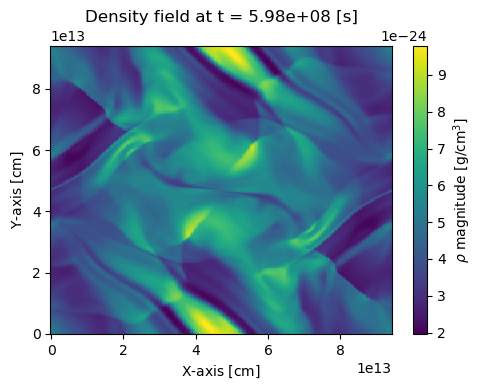

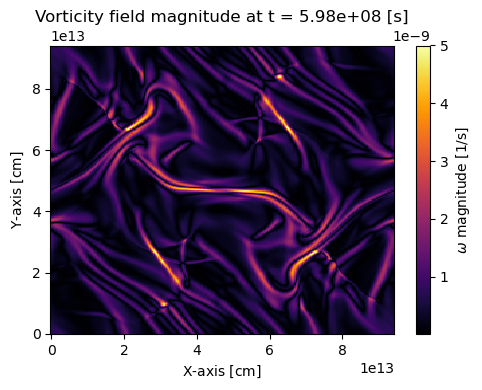

In [21]:
# 3. Call the plotting functions
plt_rho(40, data_forty, True, output_path_data_1)
plt_vorticity(40, data_forty, True, units_forty, output_path_data_1)

### (b) Create a set of Python functions that loops over all the simulation VTK files, computes the flow circulation, $\Gamma = \iint_S \vec\nabla\times \vec v \cdot \mathrm{d}\mathbf{S}$, and returns:

- a CSV file with 2 columns (time and flow circulation).

- a figure of the flow circulation versus time. Show the resulting figure in this notebook too.

First, the units of flow circulation are,
$$
(\nabla \times \vec{V}) \cdot d\vec{S} = \left[\frac{1}{T}\right][L^2] = \frac{L^2}{T}.
$$

In [22]:
def compute_flow(data_tuple, units, curl):
    """
    This function computes the flow circulation given the vorticity.
    Inputs:
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        units (tuple, it contains the normalisation units),\
        curl (array, vorticity vector field)
    Output:
        flow (float, value of the double integral)
    Author: AlejoS
    Date:11/05/2025
    """
    # 1.Get the step size
    xx = np.linspace(data_tuple[0].bounds[0], data_tuple[0].bounds[1],\
                    data_tuple[0].dimensions[0])*units[0] 
    yy = np.linspace(data_tuple[0].bounds[2], data_tuple[0].bounds[2],\
                    data_tuple[0].dimensions[1])*units[0]
    dx = abs(xx[20]-yy[21])

    # 2.Convert to 2D array
    ds = dx*np.ones((curl.shape[0], curl.shape[1]))

    # 3.Dot product
    d_product = np.dot(curl, ds)

    # 4.Compute the double integral
    flow = np.sum(d_product)

    return flow

In [23]:
def plt_flow(t, flow, boolean, output_path_data_1):
    """
    This function returns (i.e. shows or saves) high-quality labeled figures of the flow versus time.
    Inputs: 
        t (array, time),\
        flow (array, it contains the flow circulation values for each VTK file),\
        boolean (boolean, to show the plot or not),\
        output_path_data_1 (output file directory).
    Output: 
        image (image, required plot)
    Author: AlejoS
    Date: 05/04/2025
    """
    #Figure environment
    plt.figure(figsize=(7,4))

    # Plotting:
    plt.plot(t, flow, linestyle = "--", marker="o", color="teal", lw = 1.5)

    # Add title
    plt.title(f"Flow circulation vs. Time")
    
    #Axes names
    plt.xlabel(r"$\text{Time [s]}$")
    plt.ylabel(r"$\text{Flow circulation [cm²/s]}$")
    plt.grid(linestyle = "-.")
    
    #Show/Save
    plt.tight_layout()
    #Save
    plt.savefig(f"{output_path_data_1}/flow_vs_t.png")
    #Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

In [24]:
# Function to save arrays as a CSV file
def save_csv(time, arr, output_path_data_1):
    """
    This function converts the given arrays to a Pandas DataFrame. Then, saves it as a .csv file.
    Inputs: time (array),\
        arr (array),\
        output_path_data_1 (output file directory).
    Output: 
        stats.csv (CSV file)
    Author: AlejoS
    Date: 08/05/2025
    """
    # 1.Convert to a Pandas DataFrame
    calcs_df = pd.DataFrame({
        "Time [s]": time,
        "Flow circulation [cm²/s]" : arr
    })
    
    # 2.Save the data frame as .csv file:
    calcs_df.to_csv(f"{output_path_data_1}/flow_OT.csv",\
                    sep=',', float_format='{:.2e}'.format) #use scientific notation

In [25]:
def read_csv(filename):
    """
    This function reads in the created CSV file and returns the stored arrays inside a tuple.
    Input: 
        filename (str, path to file).
    Outputs: 
        t (array, time),\
        flow (array, it contains the flow circulation values for each VTK file).
    Author: AlejoS
    Date: 05/04/2025
    """
    #1. Read the CSV file
    obj = pd.read_csv(filename)

    #Retrieve the arrays
    t = np.array(obj["Time [s]"])
    flow = np.array(obj["Flow circulation [cm²/s]"])

    return t, flow

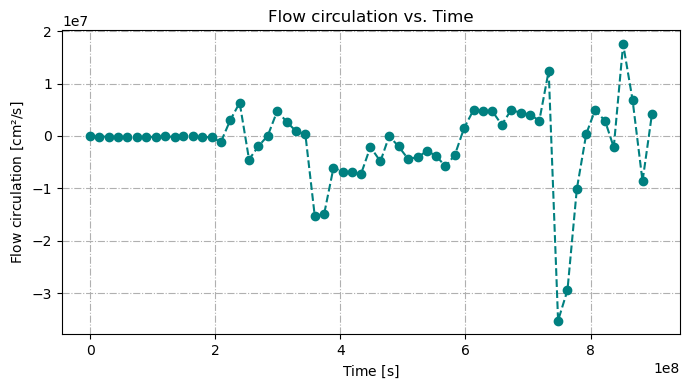

In [26]:
# Loop over the data files
# Read each data file and get the data info tuple of each one

# 1. Define an array to store the flow values
flow_array = np.zeros(61)

# 2.Iterate over all the simulation files
for j in range(0, 61):
    filename = input_path_data + "data.0{:03d}.vtk".format(j)
    #print(filename)

    # 3.Open the file j and retrieve the mesh and all the arrays
    data_tuple, units = read_sim_OT(input_path_data, filename)
    #Note that it's not necessary to create the meshgrid each time. Moreover, we already have it.

    # 4.Compute the curl of the velocity field
    v_mag, curlt = curl_mag(data_tuple, units)

    # 5.Compute the flow circulation
    flow = compute_flow(data_tuple, units, curlt)

     # 6.Store directly in the array
    flow_array[j] = flow

# 7.Save the arrays to a csv file
save_csv(data_tuple[1], flow_array, output_path_data_1)

# 8. Read the csv file
filename1 = output_path_data_1 + "/flow_OT.csv"
t, flow = read_csv(filename1)

# 9.Plot the flow circulation vs time
plt_flow(t, flow, True, output_path_data_1)

## 2. (5 points) Shock analysis:

### (c) Create a set of Python functions that isolate candidate shocked cells based on the following methods and sequentially prints the following shock candidate maps into a folder called **"output_s"** for all times:

- **Method 1:** Read the 2D velocity vector field. Compute the divergence of the velocity field and isolate the cells where there are convergent flows (i.e. where $\vec\nabla\cdot \vec v <\alpha$ with $\alpha\lesssim 0$). Cells with convergent flows are candidate shocked cells.

In [27]:
# Function 
def vel_shock_cd(data_tuple, units, index, boolean, output_path_data_2):
    """
    This function computes the divergence of the velocity field and isolates the cells where there are convergent flows. 
    Inputs: 
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        units (tuple, it contains the normalisation units),\
        index (number of file, integer),\
        boolean (boolean, to show the plot or not),\
        output_path_data_2 (str, path to save the plot).
    Outputs: 
        negative_div (array, isolated negative divergence),\
        img (image, isolated shock cell candidate).
    Author: AlejoS
    Date: 10/05/2025
    """
    # Get them to code units, since in CGS units the values are too small to work with
    vx1_code = data_tuple[3]/units[1]
    vx2_code = data_tuple[4]/units[1]
    
    # Compute the derivatives of the data
    # Spacing = 1 (we are in code units)
    grad_x = np.array(np.gradient(vx1_code, axis=1))
    grad_y = np.array(np.gradient(vx2_code, axis=0))

    # Get the total divergence
    div = grad_x + grad_y

    # Isolate the 'negative' part
    negative_div = np.where(div < -0.1, div, np.nan)

    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'Divergence of the velocity field at t = {t_stamp:.2e} [s]')
        
    negative = ax.pcolor(x_2D, y_2D, negative_div, cmap = "plasma_r", vmin = -0.2, vmax = -0.5)
    ax.set_title(r"$Isolated\,negative\,divergence$")
    ax.set_xlabel(r"$X-axis\, [cm]$")
    ax.set_ylabel(r"$Y-axis\, [cm]$")
    cb2 = plt.colorbar(negative)
    cb2.set_label(r"$Divergence\, magnitude$")
        
    #Show/Save
    plt.tight_layout()
    #Save
    plt.savefig(f"{output_path_data_2}/vel_shock_canditate_at_{index:03d}.png")
    #Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

    return negative_div

- **Method 2:** Read the 2D pressure field. Compute the gradient of the pressure and isolate the cells with large pressure gradients (i.e. where $\frac{|\vec\nabla P|}{P}>\beta\max{\left(\frac{|\vec\nabla P|}{P}\right)}$ with $\beta \lesssim 0.1$). Such cells are candidate shocked cells.

In [28]:
# Function 
def prs_shock_cd(data_tuple, units, index, boolean, output_path_data_2):
    """
    This function computes the gradient of the pressure field and isolates the cells where there are convergent flows. 
    Inputs: 
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        units (tuple, it contains the normalisation units),\
        index (number of file, integer),\
        boolean (boolean, to show the plot or not),\
        output_path_data_2 (str, path to save the plot).
    Outputs: 
        total_grad (array, isolated largest gradient),\
        img (image, isolated shock cell candidate).
    Author: AlejoS
    Date: 10/05/2025
    """
    # Get them to code units, since in CGS units the values are too small to work with
    prs_code = data_tuple[-1]/units[3]
    
    # Compute the derivatives of the data
    # Spacing = 1 (we are in code units)
    grad_x = np.array(np.gradient(prs_code, axis=1))
    grad_y = np.array(np.gradient(prs_code, axis=0))

    # Define the ratios
    ratio_x = abs(grad_x)/prs_code
    ratio_y = abs(grad_y)/prs_code

    # Isolate the largest part
    large_grad_x = np.where(ratio_x > 0.095*np.max(ratio_x), abs(grad_x), 0)
    large_grad_y = np.where(ratio_y > 0.095*np.max(ratio_y), abs(grad_y), 0)

    # Merge components
    total_grad = large_grad_x + large_grad_y
    
    # Plotting
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))

    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'Gradient of the thermal pressure field (absolute value) at t = {t_stamp:.2e} [s]')
        
    grad = ax.pcolor(x_2D, y_2D, total_grad, cmap = "cividis")#, vmin = 0., vmax = 2.)
    ax.set_title(r"$Large\,gradient\,values$")
    ax.set_xlabel(r"$X-axis\, [cm]$")
    ax.set_ylabel(r"$Y-axis\, [cm]$")
    cb2 = plt.colorbar(grad)
    cb2.set_label(r"$Gradient\, magnitude$")
        
    #Show/Save
    plt.tight_layout()
    #Save
    plt.savefig(f"{output_path_data_2}/prs_shock_canditate_at_{index:03d}.png")
    #Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

    return total_grad

### (d) Make binary maps of the resulting candidate shock cells from both methods. Show sample maps at a fixed time (VTK file # 40) in this notebook.

In [29]:
def binary_maps(map1, map2, index, boolean, output_path_data_2):
    """
    This function makes binary maps of the resulting candidate shock cells from both methods.
    Inputs:
        map1 (array, first map),\
        map2 (array, second map),\
        index (number of file, integer),\
        boolean (boolean, to show the plot or not),\
        output_path_data_2 (str, path to save the plot).
    Output:
        img (binary image)
    Author: AlejoS
    Date: 10/05/2025
    """
    # Getting the first map in binary
    negative_div_bin = np.where(map1 < 0, 1, 0)

    # Getting the second map in binary
    total_gradient_bin = np.where(map2 > 0.5, 1, 0)

    #Plotting
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'Shocked cell candidate at t = {t_stamp:.2e} [s]')
        
    neg_div = ax[0].pcolor(x_2D, y_2D, negative_div_bin , cmap = "magma_r")
    ax[0].set_title(r"$Negative\,velocity\,divergence\,values$")
    ax[0].set_xlabel(r"$X-axis\, [cm]$")
    ax[0].set_ylabel(r"$Y-axis\, [cm]$")
    cb2 = plt.colorbar(neg_div)
    cb2.set_label(r"$Divergence\, magnitude$")

    large_grad = ax[1].pcolor(x_2D, y_2D, total_gradient_bin , cmap = "magma_r")
    ax[1].set_title(r"$Large\,pressure\,gradient\,values$")
    ax[1].set_xlabel(r"$X-axis\, [cm]$")
    ax[1].set_ylabel(r"$Y-axis\, [cm]$")
    cb2 = plt.colorbar(large_grad)
    cb2.set_label(r"$Gradient\, magnitude$")
        
    #Show/Save
    plt.tight_layout()
    #Save
    plt.savefig(f"{output_path_data_2}/comparison_shock_canditate_at_{index:03d}.png")
    #Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

In [30]:
# # Loop over all files
# for j in range(0, 61):
#     filename = input_path_data + "data.0{:03d}.vtk".format(j)
#     #print(filename)

#     # 1.Open the file j and retrieve the mesh and all the arrays
#     data_tuple, units = read_sim_OT(input_path_data, filename)
#     #Note that it's not necessary to create the meshgrid each time. Moreover, we already have it.

#     # 2. Call our isolating shocked candidates functions
#     negative_div = vel_shock_cd(data_tuple, units, j, False, output_path_data_2)
#     total_grad = prs_shock_cd(data_tuple, units, j, False, output_path_data_2)

#     # 3. Call our binary map function
#     binary_maps(negative_div, total_grad, j, False, output_path_data_2)

The cell above was commented to save computational time when running the notebook, uncomment it when necessary.

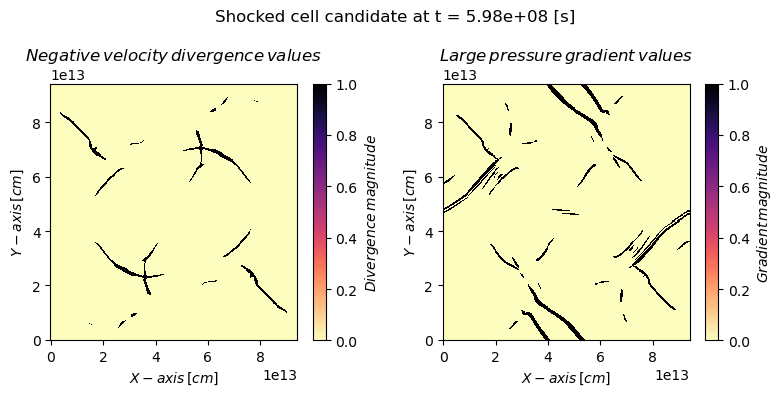

In [31]:
# Call our function for VTK file #40
# Let's check the VTK file #40
filename = input_path_data + "data.0040.vtk"
data_forty, units_forty = read_sim_OT(input_path_data, filename)

# 2. Call our isolating shocked candidates functions
negative_div = vel_shock_cd(data_forty, units_forty, 40, False, output_path_data_2)
total_grad = prs_shock_cd(data_forty, units_forty, 40, False, output_path_data_2)

# 3. Call our binary map function
binary_maps(negative_div, total_grad, 40, True, output_path_data_2)

## 3. (5 points) Fourier analysis:

### (e) Create a set of Python functions that Fourier transforms the density of any VTK file in 2D, applies high-pass and low-pass filters, smooths the density map using a 2D Gaussian, and sequentially prints the following figures into a folder called **"output_f"** for all times:

- the 2D Fourier image of the density

- the high-pass filter map

- the low-pass filter map

- the Gaussian-blurred map

Show sample maps at a fixed time (VTK file # 40) in this notebook.

In [32]:
def ff_transform(data_tuple, index, boolean, output_path_data_3):
    """
    This function computes the 2D FFT of the density map.
    Inputs: 
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        index (number of file, integer),\
        boolean (boolean, to show the plot or not),\
        output_path_data_3 (str, path to save the plot).
    Output:
        img (image, map in Fourier space).
    Author: AlejoS
    Date: 11/05/2025
    """
    # 1.Carry out the 2D FFT
    fft = np.fft.fft2(data_tuple[2])
    
    # 3.Get characteristic frequencies
    freqs_x = np.fft.fftfreq(data_tuple[2].shape[0]) #what about the sampling?
    freqs_y = np.fft.fftfreq(data_tuple[2].shape[1])

    # 4.Create the grid for Fourier space
    freqs_X, freqs_Y = np.meshgrid(sorted(freqs_x), sorted(freqs_y)) #Recall to sort the frequencies

    # 5.Shift the Fourier image, to get the low frequencies at the centre
    fft2 = np.fft.fftshift(fft)

    # 6.Get the norm of the Fourier image
    norm_fourier = np.abs(fft2)

    # 7. Plotting in Fourier space
    fig = plt.figure(figsize = (5,4))
    Z1 = plt.pcolor(freqs_X, freqs_Y, np.log10((2/norm_fourier.size)*norm_fourier),\
                    shading='auto', cmap = "Reds") # vmin = -1, vmax= 1
    
    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'2D Fourier map of the density field at t = {t_stamp:.2e} [s]')
    
    plt.colorbar(Z1)
    
    plt.xlabel(r"$k_x$")
    plt.ylabel(r"$k_y$")
    # Show/Save
    plt.tight_layout()
    # Save
    plt.savefig(f"{output_path_data_3}/fourier_dens_at_{index:03d}.png")
    # Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

    return fft2

In [33]:
def fft_filters(fft_map, index, boolean, output_path_data_3):
    """ 
    This function filters the low and high frequencies of the density map, using masking.
    Inputs: 
        fft_map(array, shifted Fourier transform map),\
        index (number of file, integer),\
        boolean (boolean, to show the plot or not),\
        output_path_data_3 (str, path to save the plot).
    Output:
        img (filtered map, in real space).
    Author: AlejoS
    Date: 11/05/2025
    """
    # 1. Masking. Define the center and the radius.
    center = [fft_map.shape[0]//2, fft_map.shape[1]//2]
    radius = 13 #may change depending on how many frequencies we want to filter out

    # 2. Construct the mask
    circle = Image.new(mode="RGB", size=(fft_map.shape[0], fft_map.shape[1]))

    draw = ImageDraw.Draw(circle)

    draw.ellipse((center[0] - radius, center[1] - radius,\
                  center[0] + radius, center[1] + radius),\
                 fill=(255, 0, 0), outline=(0, 0, 0))
    
    # 3.Convert to binary
    mask_low = np.array(circle)[:, :, 0]//255
    mask_high = -mask_low + 1

    # 4. Multiply by fft map and get the 2D inverse FFT to go back to real space.
    low_pass_map = np.fft.ifft2(np.fft.ifftshift(fft_map*mask_low))
    high_pass_map = np.fft.ifft2(np.fft.ifftshift(fft_map*mask_high))

    # 5. Plotting, in real space
    ##Low-pass image
    fig = plt.figure(figsize = (5,4))
    Z1 = plt.pcolor(x_2D, y_2D, low_pass_map.real, cmap = "viridis")#, vmin = 1.95e-24, vmax = 9.8e-24)
    
    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'Low-pass filter of the density field at t = {t_stamp:.2e} [s]')
    
    plt.colorbar(Z1)
    
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    # Show/Save
    plt.tight_layout()
    # Save
    plt.savefig(f"{output_path_data_3}/lowpass_dens_at_{index:03d}.png")
    # Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

    
    ##High-pass image
    fig = plt.figure(figsize = (5,4))
    Z1 = plt.pcolor(x_2D, y_2D, high_pass_map.real, cmap = "viridis")#, vmin = 1.95e-24, vmax = 9.8e-24)
    
    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'High-pass filter of the density field at t = {t_stamp:.2e} [s]')
    
    plt.colorbar(Z1)
    
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    # Show/Save
    plt.tight_layout()
    # Save
    plt.savefig(f"{output_path_data_3}/highpass_dens_at_{index:03d}.png")
    # Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

In [34]:
## 1. Function to generate the 2D gaussian.
def gaussian(x, y, sigma_x, sigma_y):
    """
    Function to get the 2D gaussian.
    """

    return (1/(2*np.pi*sigma_x*sigma_y) *\
            np.exp(-(x**2/(2*sigma_x**2) \
                   + y**2/(2*sigma_y**2))))

In [35]:
## 2. Generate a 2D Gaussian and do a 2D FT to it)
def mask_gauss(fft_map, index, sigma_x, sigma_y, data_tuple, boolean, output_path_data_3):
    """
    This function develops a smoothing of the density map by using a 2D Gaussian in Fourier space.
    Inputs:
        fft_map(array, shifted Fourier transform map),\
        sigma_x, sigma_y (sigmas of the gaussian along each direction).\
        data_tuple (tuple, it contains the mesh information and the retrieved arrays in cgs units),\
        index (number of file, integer),\
        boolean (boolean, to show the plot or not),\
        output_path_data_3 (str, path to save the plot).
    Output:
        img (blured map, in real space).
    """
    # We generate the vectors
    x = np.linspace(-10, 10, (data_tuple[0].dimensions[0] - 1))  # Define x coordinates
    y = np.linspace(-10, 10, (data_tuple[0].dimensions[0] - 1))  # Define y coordinates
    
    # We create the meshgrid
    X, Y = np.meshgrid(x, y)
    
    # Generate the surface
    Z = gaussian(X, Y, sigma_x, sigma_y)
    
    ## 2. FT of the gaussian, which is also a gaussian in Fourier space
    mask_3 = np.fft.fft2(Z)
    
    # Shift the low frequencies to the centre
    shifted_mask_3 = np.fft.fftshift(mask_3)
    
    ## 3. Multiply the gaussian mask by the Fourier map and shift back
    gaussian_masked_image = np.fft.ifftshift(shifted_mask_3*fft_map)

    ## 4.Then, we carry out the IFFT
    gaussian_masked_image = np.fft.ifft2(gaussian_masked_image)

    ## 5. Rolling the image
    inv_x = np.roll(gaussian_masked_image.real, gaussian_masked_image.shape[1]//2, axis = 1)
    inv_xy = np.roll(inv_x, gaussian_masked_image.shape[0]//2, axis = 0)

    ## 6.Plotting
    fig = plt.figure(figsize = (5,4))
    Z1 = plt.pcolor(x_2D, y_2D, inv_xy, cmap = "viridis")#, vmin = 0.1e-21, vmax = 8e-21)
    
    # Add title with time
    t_stamp = data_tuple[1][index]
    fig.suptitle(f'Gaussian filter of the density field at t = {t_stamp:.2e} [s]')
    
    plt.colorbar(Z1)
    
    plt.xlabel(r"$\text{X-axis [cm]}$")
    plt.ylabel(r"$\text{Y-axis [cm]}$")
    # Show/Save
    plt.tight_layout()
    # Save
    plt.savefig(f"{output_path_data_3}/gaussmask_dens_at_{index:03d}.png")
    # Show, if necessary
    if boolean:
        plt.show()
    #Close
    plt.close() #to avoid possible memory issues

/tmp/ipykernel_12117/1118418106.py:32: RuntimeWarning: divide by zero encountered in log10
  Z1 = plt.pcolor(freqs_X, freqs_Y, np.log10((2/norm_fourier.size)*norm_fourier),\


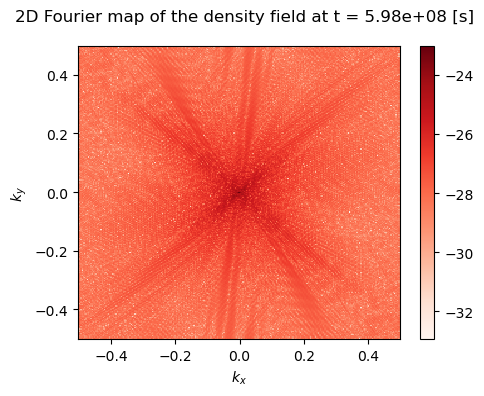

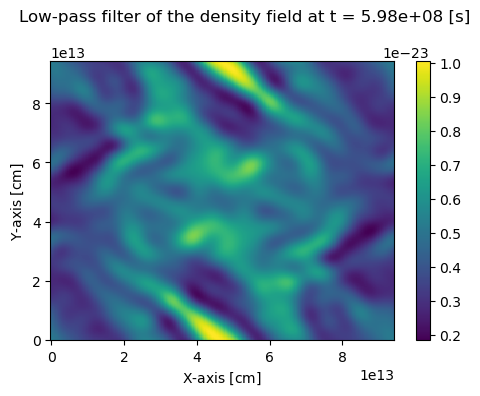

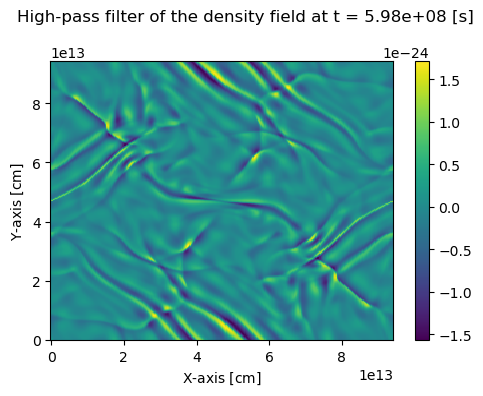

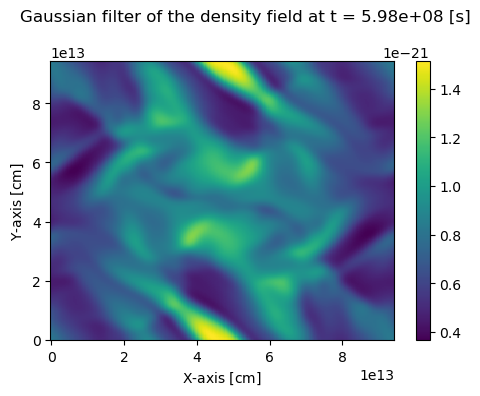

In [36]:
# Call our functions for VTK file #40
# Let's check the VTK file #40
filename = input_path_data + "data.0040.vtk"
data_forty, units_forty = read_sim_OT(input_path_data, filename)

# Call our Fourier function
shift_ff = ff_transform(data_forty, 40, True, output_path_data_3)

# Filters
fft_filters(shift_ff, 40, True, output_path_data_3)

#Gaussian mask
mask_gauss(shift_ff, 40, 0.3, 0.3, data_forty, True, output_path_data_3)

In [37]:
# # Loop over all files
# for j in range(0, 61):
#     filename = input_path_data + "data.0{:03d}.vtk".format(j)
#     #print(filename)

#     # 1.Open the file j and retrieve the mesh and all the arrays
#     data_tuple, units = read_sim_OT(input_path_data, filename)
#     #Note that it's not necessary to create the meshgrid each time. Moreover, we already have it.

#     # 2.Call our Fourier functions
#     shift_ff = ff_transform(data_tuple, j, False, output_path_data_3)

#     # 3.Call our filters
#     fft_filters(shift_ff, j, False, output_path_data_3)

#     # 4.Call our gaussian blurring
#     mask_gauss(shift_ff, j, 0.3, 0.3, data_tuple, False, output_path_data_3)

The cell above was commented to save computational time when running the notebook, uncomment it when necessary.

### (f) Create a Python function that reads in the images you wrote, and returns movies showing the time evolution of the velocity curl maps computed in (a), the high-pass filter maps in (e), and the flow circulation in (b).

In [38]:
def save_flow_snp(t_cgs, array, output_path_data_1):
    """
    This function loops over all the time values and saves the snapshots of the flow circulation.
    Inputs: 
        t_cgs (array, time_values),\
        array (array, y-data),\
        title (str, title of the plot),\
        filename (str, filename to save plot),\
        output_path_data_3 (directory, output file directory).
    Outputs: 
        img (image, saves a plot at each time instant)
    Author: AlejoS
    Data: 13/05/2025
    """
    #Loop over all time values
    for i in range(0, len(t_cgs)):
        # plt.clf()  # clear previous plot
        #Plotting
        # Figure environment
        plt.figure(figsize=(7,4))
    
        # 
        plt.plot(t_cgs[:i+1], array[:i+1], linestyle = "--", marker="o", color="teal", lw = 1.5) # to plot every point up to the current time step
    
        # Add title
        t_stamp = t_cgs[i]
        plt.title(f"Flow circulation vs. Time at t = {t_stamp:.2e} [s]")
        
         #Axes names
        plt.xlabel(r"$\text{Time [s]}$")
        plt.xlim(0e8, 9e8)
        plt.ylabel(r"$\text{Flow circulation [cm²/s]}$")
        plt.ylim(-4e7, 2e7)
        plt.grid(linestyle = "-.")

        
        #Show/Save
        plt.tight_layout()
        #Save
        plt.savefig(f"{output_path_data_1}/flow_vs_t_at_{i:03d}.png")
        plt.close() #to avoid possible memory issues

In [39]:
def movie_mkr(imgs_input, gif_output):
    """
    This function generates movies (time evolution of images) using glob.
    Inputs: 
        name_input (str, name of the snapshots),\
        name_ouput (str, name of the GIF),\
        t_cgs(array, time_values),\
        rate (array, time values),\
        title (str, title of the plot),\
        filename (str, filename to save plot),\
        output_path_data (directory, output file directory).
    Output: 
        gif
    Author: AlejoS
    Date: 13/05/2025
    """
    imgs = (Image.open(f) for f in sorted(glob.glob(imgs_input)))

    img = next(imgs)

    img.save(fp = gif_output, format="GIF", append_images=imgs,\
        save_all=True, duration = 150, loop = 0)

In [40]:
## Vorticity
input_vort = f"{output_path_data_1}/vorticity_at_***.png"
output_vort = f"{output_path_data_1}/vorticity.gif"

# 1.Call our GIF maker function
movie_mkr(input_vort, output_vort)

# 2. Display the GIF
# display.Image(open(output_vort,'rb').read()) #uncomment to show the gif

In [41]:
## High-pass density maps
input_hdens = f"{output_path_data_3}/highpass_dens_at_***.png"
output_hdens = f"{output_path_data_3}/highpass_dens.gif"

# 1.Call our GIF maker function
movie_mkr(input_hdens, output_hdens)

# 2. Display the GIF
# display.Image(open(output_hdens,'rb').read()) #uncomment to show the gif

In [42]:
## Flow circulation
# 1. Save the snapshots
save_flow_snp(data_tuple[1], flow_array, output_path_data_1)

# Define paths
input_flow = f"{output_path_data_1}/flow_vs_t_at_***.png"
output_flow = f"{output_path_data_1}/flow_circ.gif"

# 2.Call our GIF maker function
movie_mkr(input_flow, output_flow)

# 3. Display the GIF
# display.Image(open(output_flow,'rb').read()) #uncomment to show the gif

## 4. (5 points) Interpretation:

### (g) Based on your analyses above, briefly answer the following questions: 

- What information do the velocity divergence and velocity curl provide about the flow in section 1?

The velocity divergence is related with shock formation regions, for example a negative divergence would imply a compression of the fluid. The vorticity tells us the regions where there's local spinning, indicating the formation of eddies.

- Does the flow circulation reach steady state in section 1?

From the plot of flow circulation vs. time we see that it does not reach the steady state. It continues to change rapidly from time to time even at the end of the simulation.


- Do you find the same shock candidates on the maps obtained by Methods 1 and 2 in section 2?

Yes. There is just a slight mismatch at the boundaries of the maps. This is expected since they correspond to different phenomena, but overall they're similar.

  
- What do the high-pass and low-pass filter maps show in section 3?

The high-pass filters of the density field show the details (edges) of the map while the low-pass filters show the large scale structure (colors and general shapes).

  
- Are the low-pass and Gaussing blurring results consistent with one another in section 3?

Yes. Indeed, they're very similar. This is because in the low-pass filter we're enhancing the large-scale structure of the map (low frequencies in Fourier space) which is almost the same as applying a Gaussian mask at the centre, in Fourier space too.